<a href="https://colab.research.google.com/github/IbrahimBajwa313/DataSciencePrjects/blob/master/Linear_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear_Regression_Assignment







In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import os

# 1. Dataset Generation

In [ ]:
np.random.seed(42)  # for reproducibility

n_samples = 200
X = np.random.rand(n_samples, 1) * 10                # X in range [0, 10)
true_intercept = 4.0
true_slope = 3.0
noise_std = 2.0
noise = np.random.randn(n_samples, 1) * noise_std
y = true_intercept + true_slope * X + noise          # shape (n_samples, 1)


X


array([[3.74540119],
       [9.50714306],
       [7.31993942],
       [5.98658484],
       [1.5601864 ],
       [1.5599452 ],
       [0.58083612],
       [8.66176146],
       [6.01115012],
       [7.08072578],
       [0.20584494],
       [9.69909852],
       [8.32442641],
       [2.12339111],
       [1.81824967],
       [1.8340451 ],
       [3.04242243],
       [5.24756432],
       [4.31945019],
       [2.9122914 ],
       [6.11852895],
       [1.39493861],
       [2.92144649],
       [3.66361843],
       [4.56069984],
       [7.85175961],
       [1.99673782],
       [5.14234438],
       [5.92414569],
       [0.46450413],
       [6.07544852],
       [1.70524124],
       [0.65051593],
       [9.48885537],
       [9.65632033],
       [8.08397348],
       [3.04613769],
       [0.97672114],
       [6.84233027],
       [4.40152494],
       [1.22038235],
       [4.9517691 ],
       [0.34388521],
       [9.09320402],
       [2.58779982],
       [6.62522284],
       [3.11711076],
       [5.200

In [ ]:
# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 2. From-Scratch Closed-Form (Ordinary Least Squares)


In [ ]:
# Using formulas:
#   m = sum( (x - x_mean)*(y - y_mean) ) / sum( (x - x_mean)^2 )
#   b = y_mean - m * x_mean

In [ ]:
def closed_form_linear_regression(X, y):
    # X, y are 2D arrays with shape (n_samples, 1)
    x = X.flatten()
    yy = y.flatten()
    x_mean = x.mean()
    y_mean = yy.mean()
    numerator = np.sum((x - x_mean) * (yy - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    m = numerator / denominator
    b = y_mean - m * x_mean
    return m, b

m_closed, b_closed = closed_form_linear_regression(X_train, y_train)


In [ ]:

# Predictions
y_pred_closed = m_closed * X_test + b_closed


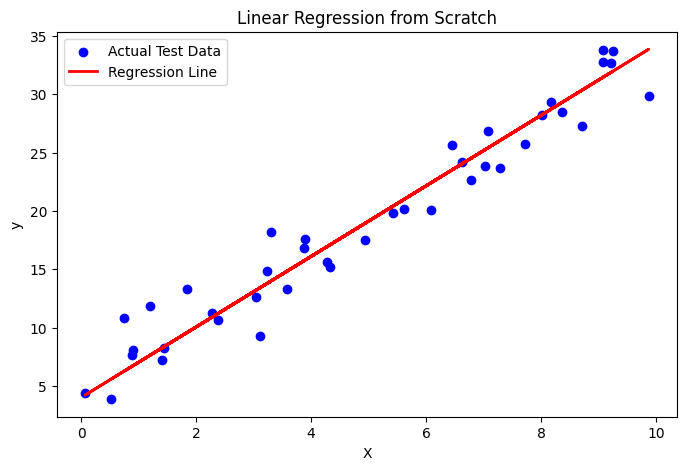

In [ ]:
# 4. Plotting
plt.figure(figsize=(8,5))

# Test data points
plt.scatter(X_test, y_test, color="blue", label="Actual Test Data")

# Regression line
plt.plot(X_test, y_pred_closed, color="red", linewidth=2, label="Regression Line")

plt.title("Linear Regression from Scratch")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# 3. scikit-learn LinearRegression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
m_lr = lr.coef_.flatten()[0]
b_lr = lr.intercept_.flatten()[0]
y_pred_lr = lr.predict(X_test)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# SGDRegressor works with 1D y arrays
sgd = SGDRegressor(max_iter=2000, tol=1e-6, learning_rate='invscaling', eta0=0.01, random_state=42)
sgd.fit(X_train_scaled, y_train.ravel())
coef_sgd_scaled = sgd.coef_.flatten()[0]
intercept_sgd = sgd.intercept_.flatten()[0]


In [ ]:
# To compare coefficients on original X scale:
# if X_scaled = (X - mean)/scale, then:
# y = coef_scaled * X_scaled + intercept = coef_scaled * (X - mean)/scale + intercept
# => y = (coef_scaled/scale) * X + (intercept - coef_scaled*mean/scale)
scale = scaler.scale_[0]
mean = scaler.mean_[0]
m_sgd = coef_sgd_scaled / scale
b_sgd = intercept_sgd - (coef_sgd_scaled * mean / scale)

y_pred_sgd = m_sgd * X_test + b_sgd


# 5. Cost Function and Evaluation
# MSE, RMSE, R2 for all three models

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

models_info = [
    ("Closed-Form (From Scratch)", y_pred_closed, m_closed, b_closed),
    ("LinearRegression (sklearn)", y_pred_lr, m_lr, b_lr),
    ("SGDRegressor (sklearn)", y_pred_sgd, m_sgd, b_sgd)
]

In [ ]:
for name, y_pred, m_val, b_val in models_info:
    mse_val = mean_squared_error(y_test, y_pred)
    rmse_val = rmse(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Slope (m)": m_val,
        "Intercept (b)": b_val,
        "MSE": mse_val,
        "RMSE": rmse_val,
        "R2": r2_val
    })

results_df = pd.DataFrame(results)


In [ ]:
# Print slope/intercept and evaluation table
pd.set_option("display.float_format", "{:.6f}".format)
print("\n=== Model Coefficients & Evaluation ===")
print(results_df)


=== Model Coefficients & Evaluation ===
                        Model  Slope (m)  Intercept (b)      MSE     RMSE  \
0  Closed-Form (From Scratch)   3.020941       4.029075 4.338495 2.082906   
1  LinearRegression (sklearn)   3.020941       4.029075 4.338495 2.082906   
2      SGDRegressor (sklearn)   3.020719       4.028173 4.337886 2.082759   

        R2  
0 0.941312  
1 0.941312  
2 0.941321  



Plot saved to: assignment_output/regression_comparison.png


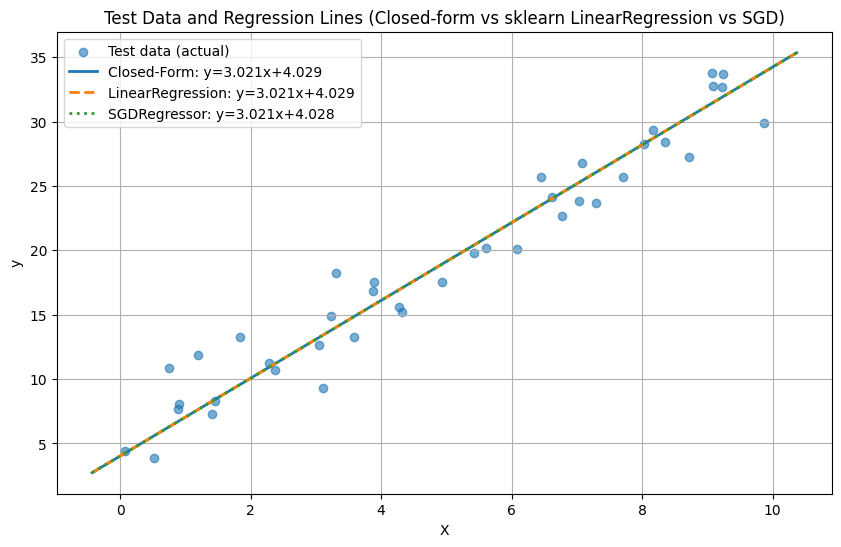

In [ ]:
# 6. Plots
# Scatter of test data + regression lines from all three models
# ----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label="Test data (actual)", alpha=0.6)

# For plotting smooth lines, sort by X
X_plot = np.linspace(X_test.min()-0.5, X_test.max()+0.5, 100).reshape(-1, 1)

# Predictions for plotting
y_plot_closed = m_closed * X_plot + b_closed
y_plot_lr = m_lr * X_plot + b_lr
y_plot_sgd = m_sgd * X_plot + b_sgd

plt.plot(X_plot, y_plot_closed, label=f"Closed-Form: y={m_closed:.3f}x+{b_closed:.3f}", linewidth=2)
plt.plot(X_plot, y_plot_lr, label=f"LinearRegression: y={m_lr:.3f}x+{b_lr:.3f}", linewidth=2, linestyle='--')
plt.plot(X_plot, y_plot_sgd, label=f"SGDRegressor: y={m_sgd:.3f}x+{b_sgd:.3f}", linewidth=2, linestyle=':')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Test Data and Regression Lines (Closed-form vs sklearn LinearRegression vs SGD)")
plt.legend()
plt.grid(True)

# Create output directory and save figure
out_dir = "assignment_output"
os.makedirs(out_dir, exist_ok=True)
plot_path = os.path.join(out_dir, "regression_comparison.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"\nPlot saved to: {plot_path}")

plt.show()


Residuals plot saved to: assignment_output/residuals_histograms.png


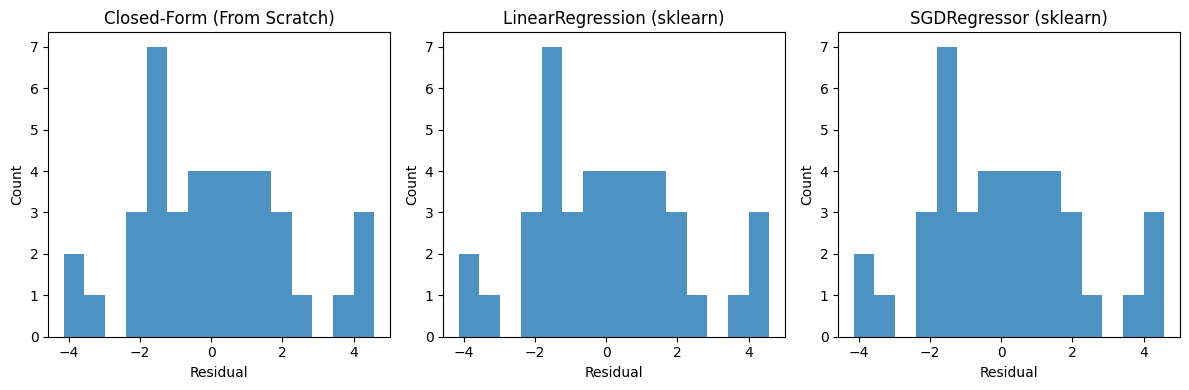

In [ ]:
# Residuals histograms
plt.figure(figsize=(12, 4))
for i, (name, y_pred, *_rest) in enumerate(models_info, start=1):
    plt.subplot(1, 3, i)
    residuals = (y_test.flatten() - y_pred.flatten())
    plt.hist(residuals, bins=15, alpha=0.8)
    plt.title(name)
    plt.xlabel("Residual")
    plt.ylabel("Count")
plt.tight_layout()
res_plot_path = os.path.join(out_dir, "residuals_histograms.png")
plt.savefig(res_plot_path, dpi=300, bbox_inches="tight")
print(f"Residuals plot saved to: {res_plot_path}")
plt.show()


MSE comparison plot saved to: assignment_output/mse_comparison.png


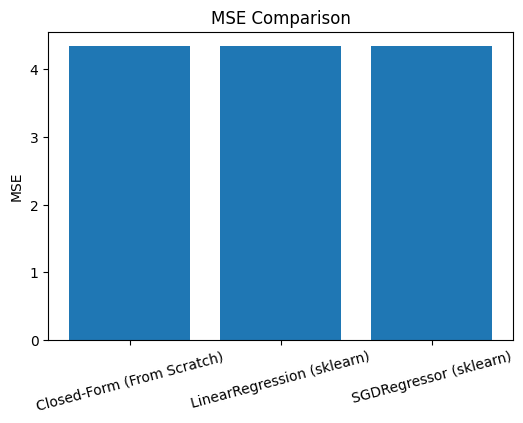

In [ ]:
# MSE bar chart
plt.figure(figsize=(6, 4))
mse_values = results_df["MSE"]
model_names = results_df["Model"]
plt.bar(model_names, mse_values)
plt.ylabel("MSE")
plt.title("MSE Comparison")
plt.xticks(rotation=15)
mse_plot_path = os.path.join(out_dir, "mse_comparison.png")
plt.savefig(mse_plot_path, dpi=300, bbox_inches="tight")
print(f"MSE comparison plot saved to: {mse_plot_path}")
plt.show()